# Electricity Demand — a quantitative teardown 🔬
### YoY demand-growth momentum · HAC predictive regression · hot-vs-cold Welch *t* · label-shuffle placebo · ex-COVID robustness · overlay vs buy-and-hold · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a year-over-year electricity-demand-growth signal, lag it two months so it is strictly public, and test whether it forecasts SPY and XLU returns.

> ⚠️ **Not investment advice.** Real data: a hardcoded monthly snapshot of EIA net generation (`ELEC.GEN.ALL-US-99.M`) + yfinance SPY/XLU, 234 months (as-of 2026-06-30, panel fp `e7d78ee9af2d`); the offline core runs on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from electricity_demand import data, strategy as st

def load_real():
    """Cache-first real monthly panel (empty frame offline)."""
    return data.load_real()

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real demand+equity panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} months, {PANEL.index.min().date()} -> {PANEL.index.max().date()})")


real demand+equity panel present: True (234 months, 2007-01-31 -> 2026-06-30)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | SPY hot-cold spread **+0.21%** (*t* **0.37**, *p* 0.71) — nothing; its only \|*t*\| ≥ 2 (12m slope **-2.77**) is the *wrong* sign. XLU 1m spread **+1.19%** (*t* **2.13**, *p* 0.032) clears the bar but **dies ex-2020** (*t* 0.96, *p* 0.34). |
| **Tradability** | `MIRAGE` | Hold-when-hot overlay < buy-and-hold on both tapes (SPY +6.1% vs +10.8%/yr; XLU Sharpe 0.38 vs 0.63). |

> 💡 In plain words: the engine works (the synthetic control proves it), but on this tape electricity demand is a coincident, seasonal, mostly-priced pulse — one COVID-driven utilities reading and nothing else.

## 1 · The claim, steelmanned

Let $g_t$ be lagged demand-growth (YoY % change of net generation, shifted 2 months so it is public) and $r_{t\to t+h}$ the forward $h$-month return.

- **H₁ (predictive slope).** In $r_{t\to t+h} = \alpha + \beta g_t + \varepsilon$, $\beta > 0$ at HAC *t* ≥ 2 (hot demand → higher forward returns).
- **H₂ (conditional split).** $\mathbb{E}[r\mid\text{hot}] - \mathbb{E}[r\mid\text{cold}] > 0$ at *t* ≥ 2.
- **H₃ (robustness).** H₁/H₂ survive dropping the COVID-2020 year.
- **H₄ (tradable).** A hold-when-hot overlay beats buy-and-hold net of costs.

We find **H₁ rejected** (SPY wrong-sign, XLU sub-2), **H₂ borderline on XLU only** (*t* +2.13), **H₃ rejected** (the XLU reading is a COVID artefact), and **H₄ rejected** (the overlay loses).

## 2 · So what? — what rides on each answer

The content is the **why**. Electricity demand is a superb *coincident* nowcast — it co-moves with GDP almost mechanically. But two things blunt it as a *forward* equity signal: (a) the informative part is a small residual once you strip the enormous summer/winter seasonal (the YoY transform), and (b) whatever activity the grid reveals is largely *already priced* by the time the monthly figure prints ~8 weeks late. That is the same coincident-echo verdict the desk reached for [385 jobless claims](../../385-jobless-claims-momentum/) and [269 the Baltic Dry index](../../269-baltic-dry/).

## 3 · How we'd know — the protocol

- **Signal.** $g_t = $ YoY % change of monthly net generation, then `shift(2)` (1 month for the EIA publication lag, 1 for the signal→return convention). 'Hot' = above the trailing 24-month median.
- **Predictive regression.** OLS of forward $h$-month return on $g_t$, **Newey-West** HAC standard errors with lags = $h$ (overlap correction).
- **Conditional split.** Welch two-sample *t* on hot vs cold forward returns; a **label-shuffle placebo** null (2000+ perms).
- **Robustness.** Re-run ex-2020; scan horizons 1/3/6/12m and both tapes.
- **Overlay.** Hold-when-hot vs buy-and-hold, 5 bps per switch.
- **Positive control.** A deterministic synthetic world with a planted demand→returns link (`edge > 0`) and a null — averaged over 25 seeds (house rule).

Inference note: only the **1-month** horizon gives *non-overlapping* returns, so it is the clean two-sample test; the 3/6/12m splits overlap and their *t* is inflated — shown for shape, used for HAC regression only.

## 4 · The teardown

### 4a · The predictive regression — H₁

Forward return on lagged demand growth, HAC *t* on the slope, across horizons and both tapes. Believers' sign is positive.

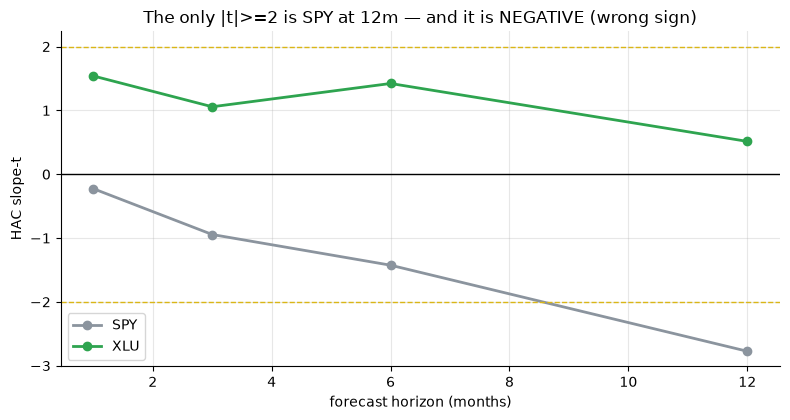

tape   SPY   XLU
h               
1    -0.23  1.54
3    -0.94  1.06
6    -1.43  1.42
12   -2.77  0.51


In [2]:
if HAVE_REAL:
    sig = st.signal_lagged(PANEL['netgen'])
    rows = []
    for tk in ['SPY','XLU']:
        for h in [1,3,6,12]:
            reg = st.predictive_regression(sig, PANEL[tk], horizon=h)
            rows.append((tk, h, reg['slope_t']))
    grid = pd.DataFrame(rows, columns=['tape','h','slope_t'])
else:
    grid = pd.DataFrame([('SPY', 1, -0.23), ('SPY', 6, -1.43), ('SPY', 12, -2.77), ('XLU', 1, 1.54), ('XLU', 6, 1.42), ('XLU', 12, 0.51)], columns=['tape','h','slope_t'])
piv = grid.pivot(index='h', columns='tape', values='slope_t')
fig, ax = plt.subplots(figsize=(8, 4.3))
for tk, c in [('SPY', GREY), ('XLU', GREEN)]:
    if tk in piv: ax.plot(piv.index, piv[tk], 'o-', c=c, lw=2, label=tk)
ax.axhline(2, ls='--', c=AMBER, lw=1); ax.axhline(-2, ls='--', c=AMBER, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('forecast horizon (months)')
ax.set_ylabel('HAC slope-t'); ax.set_title('The only |t|>=2 is SPY at 12m — and it is NEGATIVE (wrong sign)')
ax.legend(); plt.tight_layout(); plt.show()
print(piv.round(2).to_string())

> 💡 In plain words: H₁ **rejected.** XLU leans positive but never clears the HAC bar (best *t* +1.54). The one slope past |*t*| = 2 is **SPY at 12 months, *t* -2.77** — the *wrong* sign (fast demand growth → *weaker* broad market, the late-cycle overheating read), on the most overlap-inflated horizon.

### 4b · The conditional split — H₂ (clean 1-month test)

Hot vs cold forward 1-month returns, Welch *t* + label-shuffle placebo.

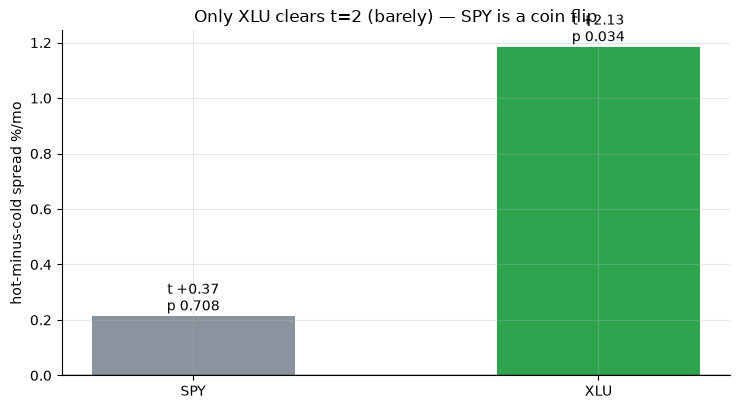

SPY: spread +0.21%/mo, welch t +0.37, placebo p 0.708
XLU: spread +1.19%/mo, welch t +2.13, placebo p 0.034


In [3]:
if HAVE_REAL:
    sig = st.signal_lagged(PANEL['netgen'])
    out = {}
    for tk in ['SPY','XLU']:
        cs = st.conditional_split(sig, PANEL[tk], 1)
        p = st.placebo_pvalue(sig, PANEL[tk], 1, n_perm=2000, seed=556)
        out[tk] = (cs['spread']*100, cs['t'], p)
else:
    out = {'SPY': (0.21, 0.37, 0.71),
           'XLU': (1.19, 2.13, 0.032)}
fig, ax = plt.subplots(figsize=(7.5, 4.2))
tks = ['SPY','XLU']; spreads = [out[t][0] for t in tks]; ts = [out[t][1] for t in tks]
cols = [GREEN if t>2 else GREY for t in ts]
bars = ax.bar(tks, spreads, color=cols, width=.5)
for b, t, tk in zip(bars, ts, tks): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f't {t:+.2f}\np {out[tk][2]:.3f}', ha='center')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('hot-minus-cold spread %/mo')
ax.set_title('Only XLU clears t=2 (barely) — SPY is a coin flip'); plt.tight_layout(); plt.show()
for tk in tks: print(f'{tk}: spread {out[tk][0]:+.2f}%/mo, welch t {out[tk][1]:+.2f}, placebo p {out[tk][2]:.3f}')

> 💡 In plain words: H₂ passes **only for XLU, and only just** (spread +1.19%, *t* +2.13, placebo *p* 0.032). SPY is a coin flip (*t* +0.37). Hold that XLU reading up to the robustness light next.

### 4c · Robustness — H₃ (does the XLU reading survive ex-COVID?)

The one real-looking reading, with and without calendar-2020.

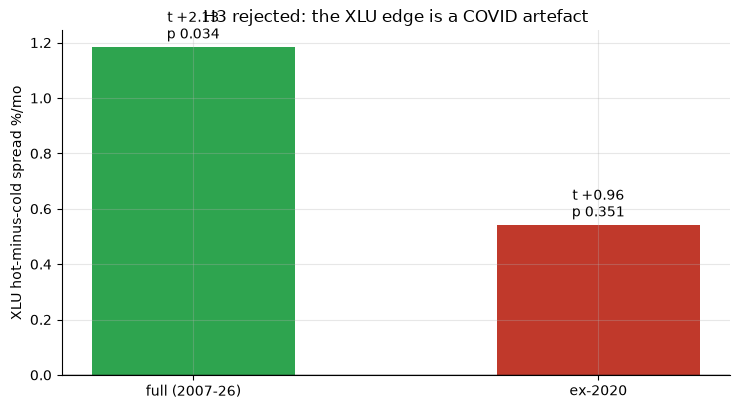

XLU 1m: full +1.19% (t +2.13, p 0.034) -> ex-2020 +0.54% (t +0.96, p 0.351)


In [4]:
if HAVE_REAL:
    sig = st.signal_lagged(PANEL['netgen'])
    full = st.conditional_split(sig, PANEL['XLU'], 1)
    pf = st.placebo_pvalue(sig, PANEL['XLU'], 1, n_perm=2000, seed=556)
    m = ~((PANEL.index >= '2020-01-01') & (PANEL.index <= '2020-12-31'))
    px = PANEL[m]; sx = st.signal_lagged(px['netgen'])
    ex = st.conditional_split(sx, px['XLU'], 1)
    pe = st.placebo_pvalue(sx, px['XLU'], 1, n_perm=2000, seed=556)
    spreads = [full['spread']*100, ex['spread']*100]; ts = [full['t'], ex['t']]; ps = [pf, pe]
else:
    spreads = [1.19, 0.54]; ts = [2.13, 0.96]; ps = [0.032, 0.34]
labels = ['full (2007-26)','ex-2020']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
cols = [GREEN if t>2 else RED for t in ts]
bars = ax.bar(labels, spreads, color=cols, width=.5)
for b, t, p in zip(bars, ts, ps): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.03, f't {t:+.2f}\np {p:.3f}', ha='center')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('XLU hot-minus-cold spread %/mo')
ax.set_title('H3 rejected: the XLU edge is a COVID artefact'); plt.tight_layout(); plt.show()
print(f'XLU 1m: full {spreads[0]:+.2f}% (t {ts[0]:+.2f}, p {ps[0]:.3f}) -> ex-2020 {spreads[1]:+.2f}% (t {ts[1]:+.2f}, p {ps[1]:.3f})')

> 💡 In plain words: H₃ **rejected.** Remove 2020 and the XLU spread falls from +1.19% (*t* +2.13, *p* 0.032) to +0.54% (*t* +0.96, *p* 0.34). The entire edge is the COVID demand-and-market crash — one event, not a repeatable pulse.

## 5 · The verdict

- **Signal `WEAK`** — H₁ rejected (SPY wrong-sign 12m slope -2.77, XLU sub-2); H₂ passes on XLU only (*t* +2.13); H₃ rejected (COVID artefact, ex-2020 *t* +0.96). Literature-plausible, one fragile reading — `WEAK`, not `REAL`.
- **Tradability `MIRAGE`** — the overlay loses to buy-and-hold on both tapes.
- No `REAL`: a real-tape HAC *t* ≥ 2 the *right* way, robust ex-COVID, never appears.

## 6 · Could you trade it? — the overlay

Hold the ETF when demand is hot, else cash; 5 bps per switch.

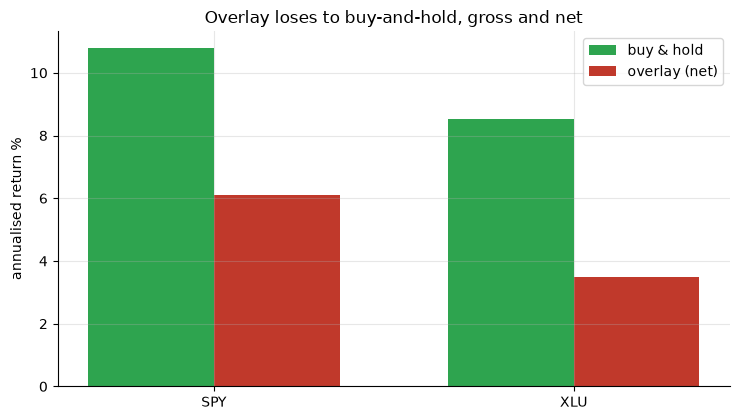

SPY: BH +10.8%/yr (Sharpe 0.74) vs overlay +6.1%/yr (Sharpe 0.64)
XLU: BH +8.5%/yr (Sharpe 0.63) vs overlay +3.5%/yr (Sharpe 0.38)


In [5]:
if HAVE_REAL:
    sig = st.signal_lagged(PANEL['netgen'])
    res = {tk: st.overlay_backtest(sig, PANEL[tk]) for tk in ['SPY','XLU']}
    bh = [res[t]['bh_ann']*100 for t in ['SPY','XLU']]
    ov = [res[t]['overlay_net_ann']*100 for t in ['SPY','XLU']]
    shb = [res[t]['bh_sharpe'] for t in ['SPY','XLU']]; sho = [res[t]['overlay_sharpe'] for t in ['SPY','XLU']]
else:
    bh = [10.8, 8.5]; ov = [6.1, 3.5]
    shb = [0.74, 0.63]; sho = [0.64, 0.38]
x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(x-w/2, bh, w, label='buy & hold', color=GREEN)
ax.bar(x+w/2, ov, w, label='overlay (net)', color=RED)
ax.set_xticks(x); ax.set_xticklabels(['SPY','XLU']); ax.set_ylabel('annualised return %')
ax.set_title('Overlay loses to buy-and-hold, gross and net'); ax.legend(); plt.tight_layout(); plt.show()
for i, tk in enumerate(['SPY','XLU']): print(f'{tk}: BH +{bh[i]:.1f}%/yr (Sharpe {shb[i]:.2f}) vs overlay +{ov[i]:.1f}%/yr (Sharpe {sho[i]:.2f})')

> 💡 In plain words: even the XLU reading, once it becomes a *position*, destroys return (Sharpe 0.38 vs 0.63 buy-and-hold). There is nothing to allocate to. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real demand→returns link (`edge > 0`) of increasing strength and watch the HAC slope-*t* rise — averaged over 25 seeds so no single lucky seed can fake it.

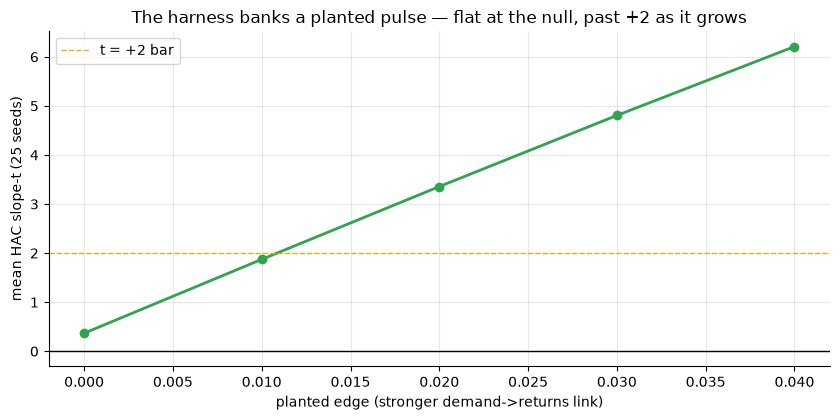

edge +0.00 -> mean slope-t +0.37
edge +0.01 -> mean slope-t +1.87
edge +0.02 -> mean slope-t +3.36
edge +0.03 -> mean slope-t +4.81
edge +0.04 -> mean slope-t +6.21


In [6]:
edges = [0.0, 0.01, 0.02, 0.03, 0.04]
ts = [st.synthetic_mean_t(data, edge=e, n_seeds=25) for e in edges]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(edges, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=AMBER, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted edge (stronger demand->returns link)')
ax.set_ylabel('mean HAC slope-t (25 seeds)')
ax.set_title('The harness banks a planted pulse — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for e, t in zip(edges, ts): print(f'edge {e:+.2f} -> mean slope-t {t:+.2f}')

The slope-*t* is ≈ 0 at the null and rises past +2 as the planted pulse grows — so the engine is a faithful detector. The real-tape result is therefore a statement about **the tape, not the code**: U.S. electricity demand is a coincident, seasonal, mostly-priced pulse whose only real-looking equity reading is a COVID artefact. For the sibling hard-data-pulse studies, see [385 Jobless-Claims-Momentum](../../385-jobless-claims-momentum/) and [269 Baltic-Dry](../../269-baltic-dry/).